## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в банку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score
import shap

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bank-additional-full.csv', sep=';')

In [4]:
print(f"Розмір датасету: {df.shape}")
display(df.head())
print(df.info())

Розмір датасету: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Розподіл цільової змінної:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


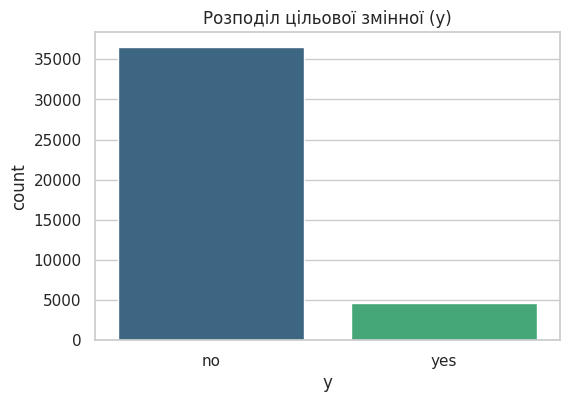

In [5]:
target_counts = df['y'].value_counts(normalize=True) * 100
print(f"Розподіл цільової змінної:\n{target_counts}")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis', hue='y', legend=False)
plt.title('Розподіл цільової змінної (y)')
plt.show()

Cильний дисбаланс цільової змінної, приблизно 89% - no  і 11% - yes

In [6]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

target = 'y'
categorical_cols = df.select_dtypes(include=['object']).columns.drop(target).tolist()
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

print(f"Категоріальні ознаки: {len(categorical_cols)}")
print(f"Числові ознаки: {len(numeric_cols)}")

Категоріальні ознаки: 10
Числові ознаки: 10



Графіки для категоріальних ознак:


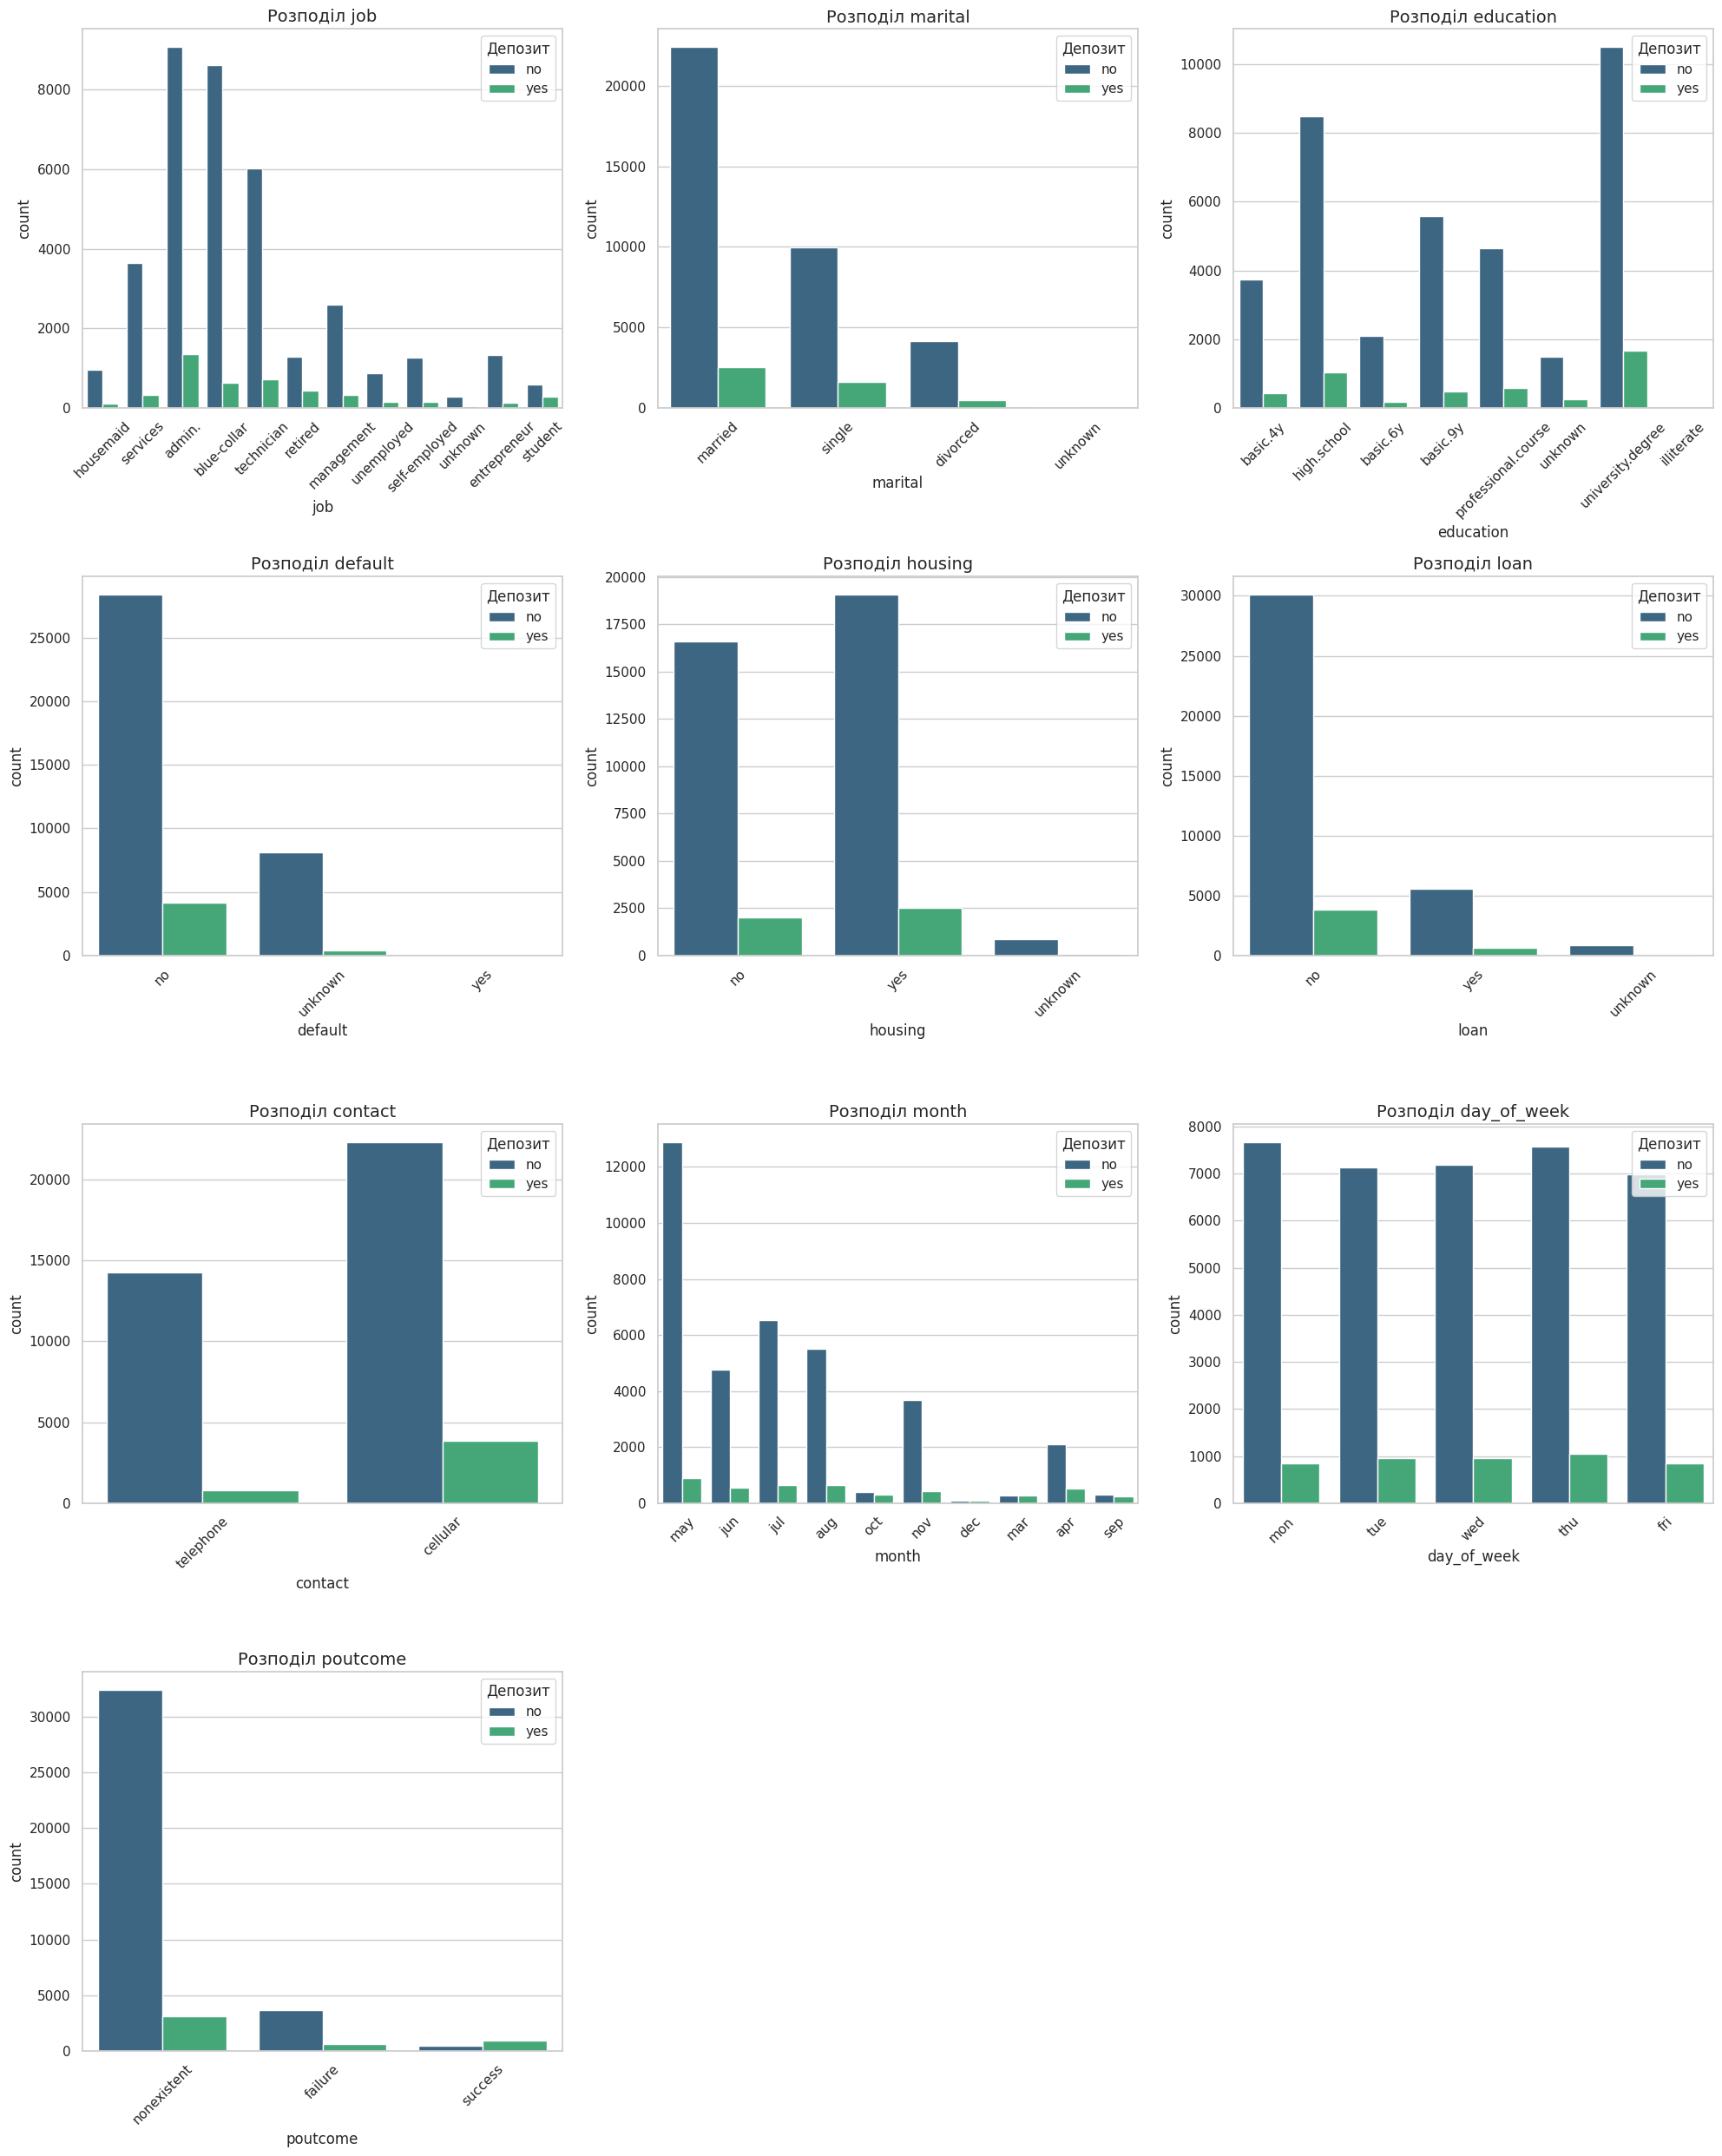

In [7]:
print("\nГрафіки для категоріальних ознак:")
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue=target, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Розподіл {col}', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Депозит', loc='upper right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Графіки для числових ознак:


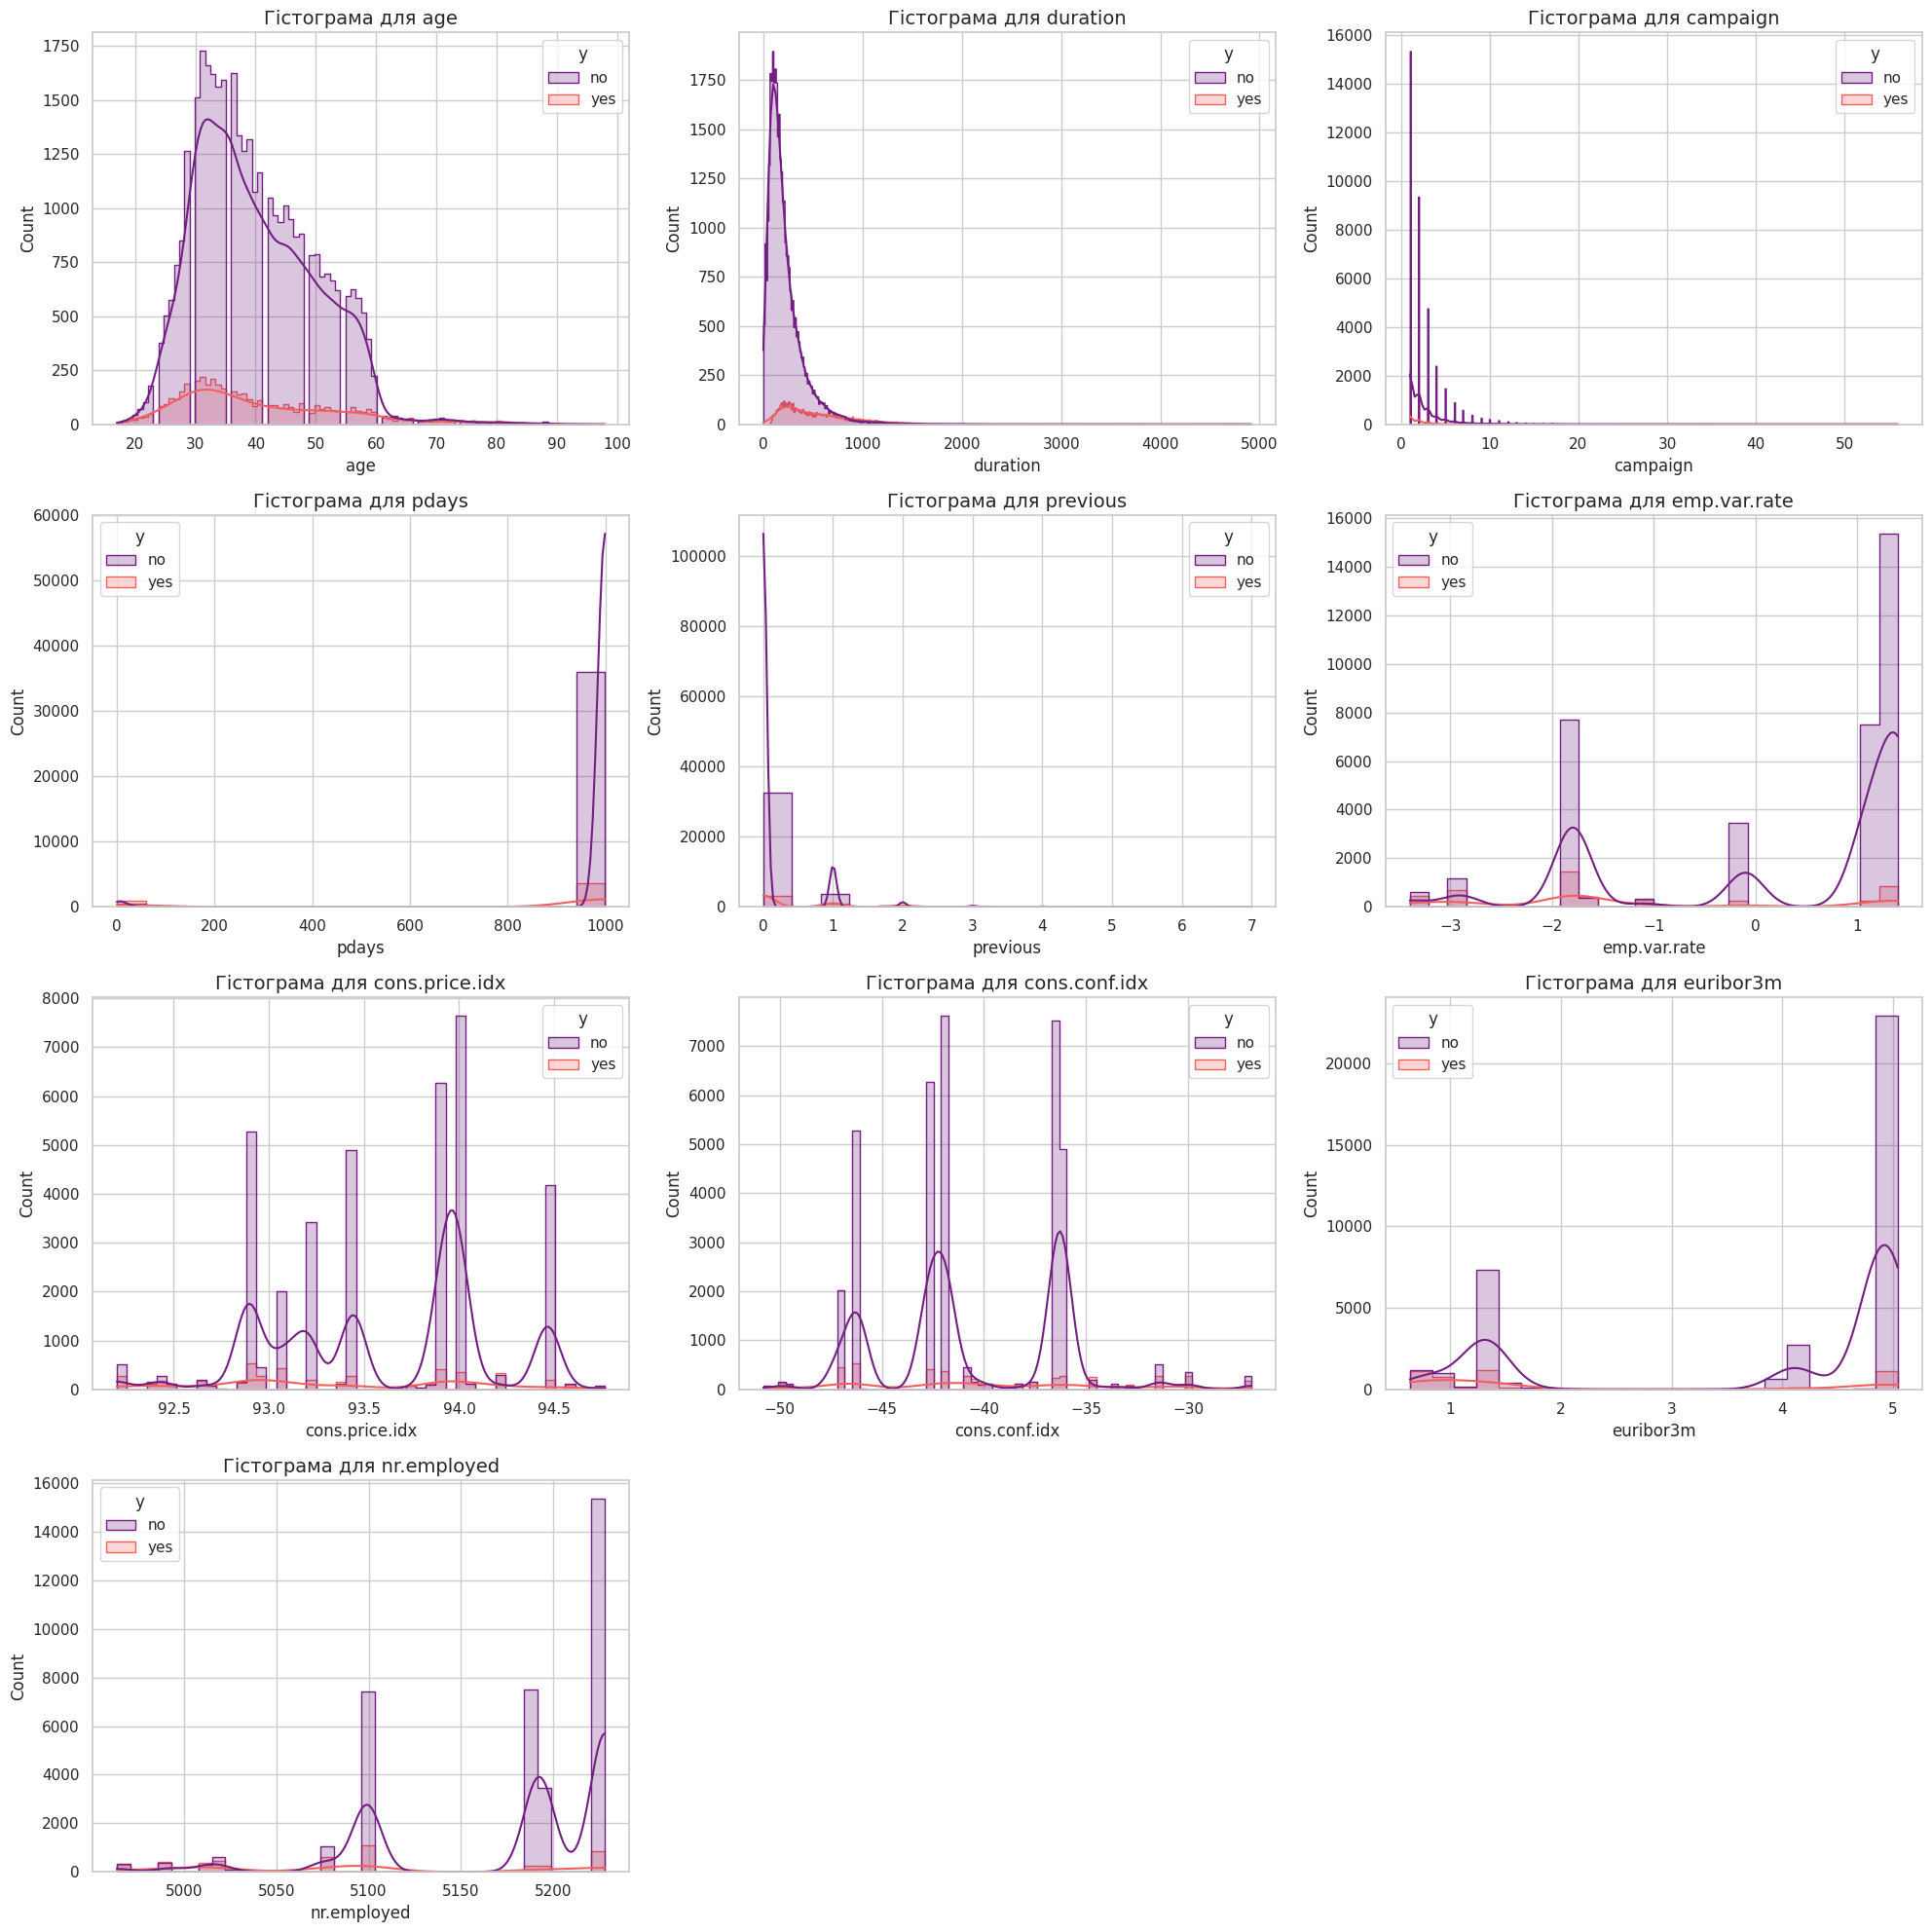

In [8]:
print("\nГрафіки для числових ознак:")
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue=target, ax=axes[i], kde=True, element="step", palette='magma')
    axes[i].set_title(f'Гістограма для {col}', fontsize=14)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Матриця кореляції


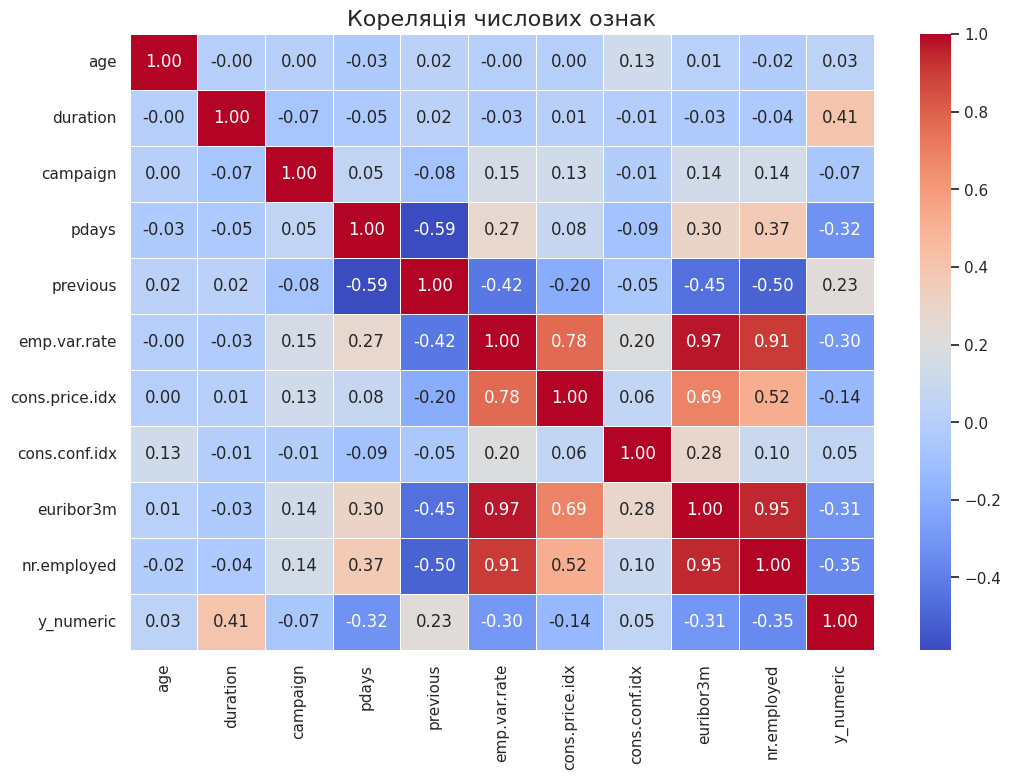

In [9]:
print("\nМатриця кореляції")
plt.figure(figsize=(12, 8))
df_corr = df.copy()
df_corr['y_numeric'] = df_corr['y'].map({'yes': 1, 'no': 0})

correlation_matrix = df_corr[numeric_cols + ['y_numeric']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Кореляція числових ознак', fontsize=16)
plt.show()

1. Найбільш схильними до відкриття депозитів є студенти (students) та пенсіонери (retired).
2. Важливим є попередній досвід (poutcome). Клієнти, чия попередня маркетингова кампанія була успішною, демонструють високу ймовірність погодитися знову.
3. (contact) - дзвінки на мобільні мають вищу конверсію порівняно зі стаціонарними, що свідчить про важливість персоналізованого контакту.
4. (duration) - сильний позитивний зв'язок між тривалістю дзвінка та успіхом операції.
5. (pdays) - більшість клієнтів нові, а ті, з ким контактували недавно, погоджуються частіше.
6. Сильна кореляцію між (euribor3m), (emp.var.rate) та (nr.employed), вони рухаються синхронно і впливають на готовність людей до інвестицій. Мають високу від'ємну кореляцію з успіхом дзвінка.

Так як є сильний дисбаланс класів, ми не можемо використовувати Accuracy. Будемо використовувати ROC-AUC для оцінки загальної роздільної здатності (здатність моделі ранжувати клієнтів) та F1-score для оцінки балансу точності та повноти. Для банку важливо знайти баланс, щоб не витрачати ресурси на даремні дзвінки, але й не втрачати клієнтів.


Для цього проєкту використаємо чотири різних підходи.
1. Logistic Regression. Проста, швидка та інтерпретована.
2. kNN. Допоможе знайти клієнтів, які поводяться так само, як ті, хто вже відкрив депозит.
3. Decision Tre. Дозволяє виявити нелінійні правила.
4. XGBoost. Модель будує ансамблі з дерев, де кожне наступне виправляє помилки попередніх.

Ці методи обрані, тому що вони покривають спектр від найпростіших (де ми бачимо вплив кожного фактора) до найскладніших (де ми отримуємо максимальну точність).

In [10]:
X = df.drop(columns=['y', 'duration'])
y = df['y'].map({'yes': 1, 'no': 0})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
def clean_categories(df_input):
  df_res = df_input.copy()
  education_map = {
      'basic.4y': 'basic', 'basic.6y': 'basic', 'basic.9y': 'basic',
      'high.school': 'high.school', 'university.degree': 'university.degree',
      'professional.course': 'professional.course', 'unknown': 'unknown', 'illiterate': 'unknown'
  }
  df_res['education'] = df_res['education'].map(education_map)
  return df_res

X_train = clean_categories(X_train)
X_val = clean_categories(X_val)

In [12]:
def feature_engineering(df_input):
  df_res = df_input.copy()
  df_res['was_contacted'] = (df_res['pdays'] != 999).astype(int)
  df_res['is_retired_age'] = (df_res['age'] >= 60).astype(int)
  return df_res

X_train = feature_engineering(X_train)
X_val = feature_engineering(X_val)

In [13]:
def handle_outliers(df_input, columns=['age', 'campaign']):
  df_res = df_input.copy()
  for col in columns:
    upper_limit = df_res[col].quantile(0.99)
    df_res[col] = np.where(df_res[col] > upper_limit, upper_limit, df_res[col])
  return df_res

X_train = handle_outliers(X_train)
X_val = handle_outliers(X_val)

In [14]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

X_train_final = preprocessor.fit_transform(X_train)
X_val_final = preprocessor.transform(X_val)

cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(encoded_cat_names)

print(f"Кількість ознак: {len(feature_names)}")

Кількість ознак: 61


In [15]:
def evaluate_model(model, X_train, y_train, X_val, y_val, name):
  model.fit(X_train, y_train)

  train_probs = model.predict_proba(X_train)[:, 1]
  val_probs = model.predict_proba(X_val)[:, 1]
  val_preds = model.predict(X_val)

  train_auc = roc_auc_score(y_train, train_probs)
  val_auc = roc_auc_score(y_val, val_probs)
  val_f1 = f1_score(y_val, val_preds)

  print(name)
  print(f"AUROC Train: {train_auc:.4f}")
  print(f"AUROC Val: {val_auc:.4f}")
  print(f"F1-score Val: {val_f1:.4f}")

  return {
      'model_name': name,
      'train_auc': train_auc,
      'val_auc': val_auc,
      'val_f1': val_f1
  }

results = []

In [16]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
results.append(evaluate_model(log_reg, X_train_final, y_train, X_val_final, y_val, "Logistic Regression"))

Logistic Regression
AUROC Train: 0.7949
AUROC Val: 0.8011
F1-score Val: 0.4723


In [17]:
knn = KNeighborsClassifier(n_neighbors=100)
results.append(evaluate_model(knn, X_train_final, y_train, X_val_final, y_val, "kNN"))

kNN
AUROC Train: 0.8114
AUROC Val: 0.7987
F1-score Val: 0.3225


In [18]:
dt = DecisionTreeClassifier(max_depth=9, random_state=42, class_weight='balanced', min_samples_leaf=160, criterion='entropy')
results.append(evaluate_model(dt, X_train_final, y_train, X_val_final, y_val, "Decision Tree"))

Decision Tree
AUROC Train: 0.8070
AUROC Val: 0.8078
F1-score Val: 0.4732


In [37]:
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, scale_pos_weight = 5, reg_alpha=0.1)
results.append(evaluate_model(xgb, X_train_final, y_train, X_val_final, y_val, "XGBoost"))

XGBoost
AUROC Train: 0.8510
AUROC Val: 0.8134
F1-score Val: 0.5308


| Назва моделі | Гіперпараметри | AUROC (Train) | AUROC (Val) / F1 (Val) |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | `max_iter=1000`, `random_state=42`, `class_weight='balanced'` | 0.7949 | 0.8011 / 0.4723 |
| **kNN** | `n_neighbors=100` | 0.8114 | 0.7987 / 0.3225 |
| **Decision Tree** | `max_depth=9`, `min_samples_leaf=160`, `class_weight='balanced'`, `criterion='entropy'` | 0.8070 | 0.8078 / 0.4732 |
| **XGBoost** | `n_estimators=100`, `max_depth=5`, `scale_pos_weight=5`, `learning_rate=0.1`, `reg_alpha=0.1`| 0.8510 | 0.8153 / 0.4902 |

1. Хороша модель. Відсутнє перенавчання. Ідея: спробувати Polynomial Features для виявлення нелінійних зв'язків.
2. Посередня модель. Збільшення k до 100 допомогло уникнути перенавчання, але F1-score найнижчий серед усіх.
3. Хороша модель. Результати майже ідентичні логістичній регресії.
4. Найкраща модель. Має найвищі показники AUROC та F1. Ідея: провести тюнінг за допомогою Hyperopt.

Оскільки XGBoost виявився лідером у порівнянні, використаємо дві різні стратегії пошуку гіперпараметрів.



In [24]:
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [3, 4, 5, 6, 7, 8, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_final, y_train)

print(f"Найкращі параметри RandomizedSearch: {random_search.best_params_}")
print(f"Найкращий крос-валідаційний AUROC: {random_search.best_score_:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:30:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Найкращі параметри RandomizedSearch: {'subsample': 0.8, 'scale_pos_weight': 5, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Найкращий крос-валідаційний AUROC: 0.7962


In [27]:
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 500, 50),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10),
    'reg_alpha': hp.uniform('reg_alpha', 0, 5),
    'reg_lambda': hp.uniform('reg_lambda', 0, 5)
}

def objective(params):
  params['n_estimators'] = int(params['n_estimators'])
  params['max_depth'] = int(params['max_depth'])

  model = XGBClassifier(**params, random_state=42, use_label_encoder=False, eval_metric='logloss')

  auc = cross_val_score(model, X_train_final, y_train, cv=3, scoring='roc_auc').mean()

  return {'loss': 1 - auc, 'status': STATUS_OK}

trials = Trials()
best_hyperopt = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials, rstate=np.random.default_rng(42))

print(f"\nНайкращі параметри (Hyperopt): {best_hyperopt}")

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:41:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:41:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:41:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  5%|▌         | 1/20 [00:03<01:12,  3.82s/trial, best loss: 0.21645493741466926]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:41:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:41:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:41:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 10%|█         | 2/20 [00:07<01:05,  3.66s/trial, best loss: 0.21645493741466926]

...

 90%|█████████ | 18/20 [01:51<00:08,  4.13s/trial, best loss: 0.20555960343108692]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 95%|█████████▌| 19/20 [01:59<00:05,  5.28s/trial, best loss: 0.20555960343108692]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



100%|██████████| 20/20 [02:03<00:00,  6.16s/trial, best loss: 0.20555960343108692]

Найкращі параметри (Hyperopt): {'colsample_bytree': np.float64(0.8334126409787352), 'learning_rate': np.float64(0.020146521712146016), 'max_depth': np.float64(7.0), 'n_estimators': np.float64(150.0), 'reg_alpha': np.float64(3.5223000813752336), 'reg_lambda': np.float64(2.962267066629037), 'scale_pos_weight': np.float64(2.909954052940017), 'subsample': np.float64(0.7615110681047916)}


In [28]:
rs_params = random_search.best_params_

final_xgb_rs = XGBClassifier(**rs_params, random_state=42)

final_xgb_rs.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_parallel_tree=None, ...)

In [29]:
hyp_params = best_hyperopt.copy()

if 'n_estimators' in hyp_params:
    hyp_params['n_estimators'] = int(hyp_params['n_estimators'])
if 'max_depth' in hyp_params:
    hyp_params['max_depth'] = int(hyp_params['max_depth'])

final_xgb_hyper = XGBClassifier(**hyp_params, random_state=42)

final_xgb_hyper.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.8334126409787352), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.020146521712146016), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [30]:
auc_rs = roc_auc_score(y_val, final_xgb_rs.predict_proba(X_val_final)[:, 1])

auc_hyper = roc_auc_score(y_val, final_xgb_hyper.predict_proba(X_val_final)[:, 1])

print(f"AUROC Val (RandomizedSearch): {auc_rs:.4f}")
print(f"AUROC Val (Hyperopt):         {auc_hyper:.4f}")

AUROC Val (RandomizedSearch): 0.8129
AUROC Val (Hyperopt):         0.8186


In [38]:
val_preds = final_xgb_hyper.predict(X_val_final)
val_f1 = f1_score(y_val, val_preds)

print(f"F1-score Val: {val_f1:.4f}")

F1-score Val: 0.5331


Порівняння на валідаційних даних показало, що підхід Hyperopt забезпечив вищий AUROC 0.8186, що робить цю модель фінальним вибором для проєкту.

/tmp/ipykernel_9065/2779736245.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma')


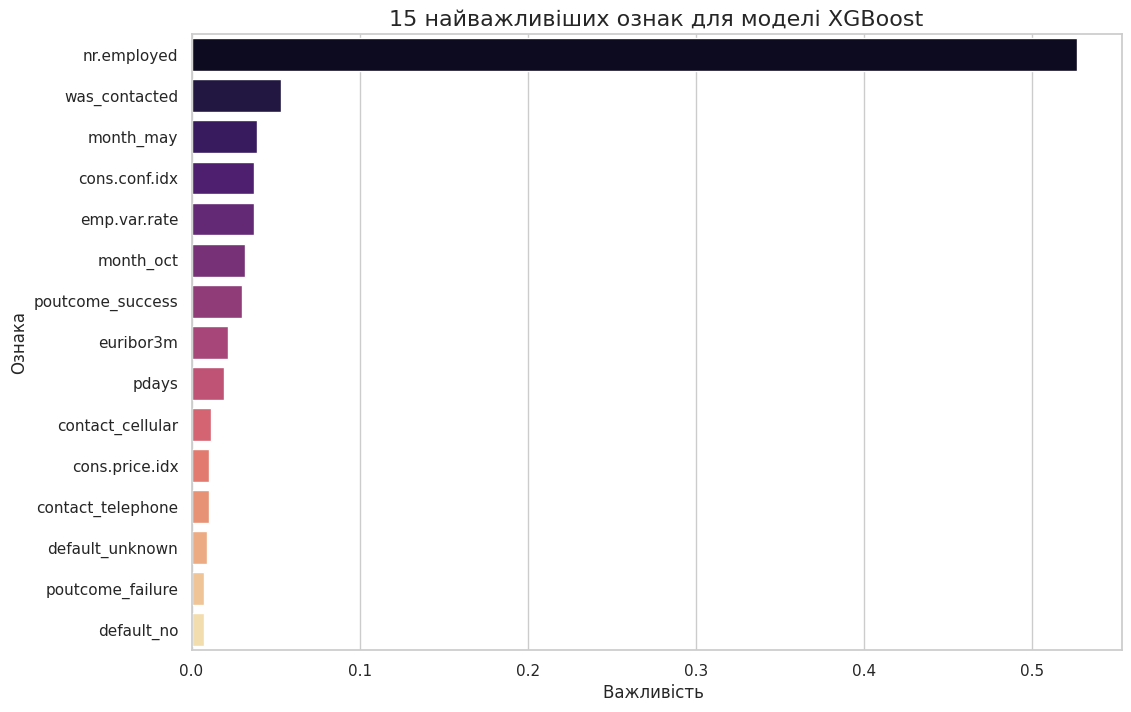

In [31]:
importances = final_xgb_hyper.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma')
plt.title('15 найважливіших ознак для моделі XGBoost', fontsize=16)
plt.xlabel('Важливість ', fontsize=12)
plt.ylabel('Ознака', fontsize=12)
plt.show()

Такий пріоритет важливості ознак є адекватним та раціональним. Модель пріоритезує зовнішні економічні чинники, історію успіху попередніх контактів та сезонність, що відповідає роботі банківського сектору.

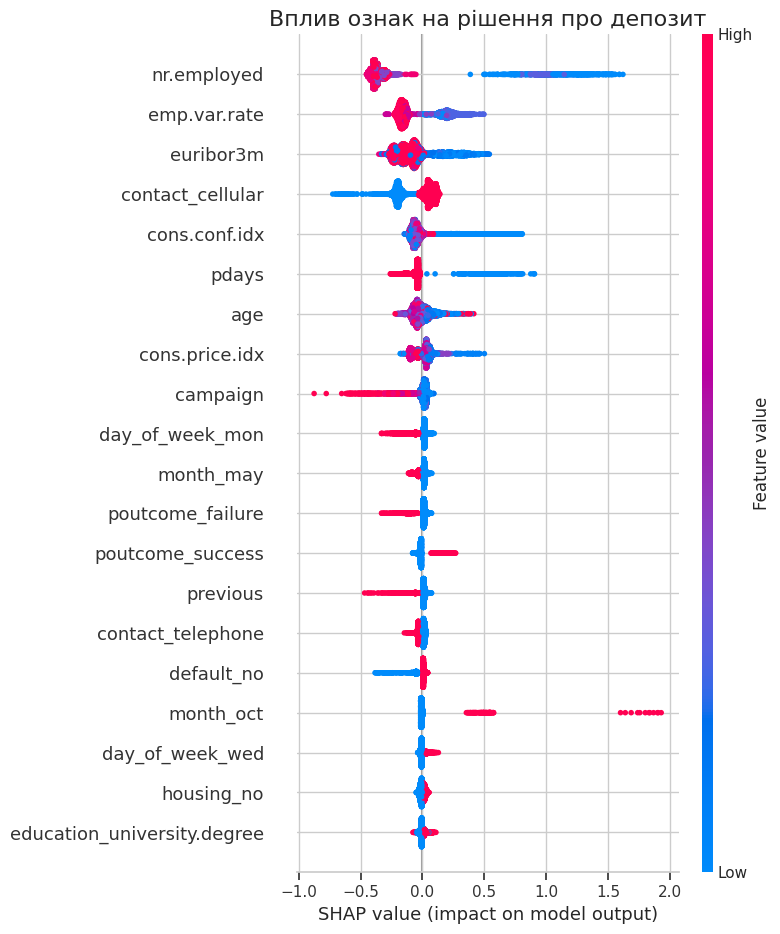

In [33]:
explainer = shap.TreeExplainer(final_xgb_hyper)
shap_values = explainer.shap_values(X_val_final)

plt.title("Вплив ознак на рішення про депозит", fontsize=16)
shap.summary_plot(shap_values, X_val_final, feature_names=feature_names)

Для прийняття рішень модель спочатку оцінює загальну економічну ситуацію в країні, потім оцінюється успішність попередньої історії взаємодії з клієнтом, після цього враховує сезонність та особисті характеристики клієнтів. Така схема є логічною для банківського сектора.

In [35]:
threshold = 0.5
y_val_probs = final_xgb_hyper.predict_proba(X_val_final)[:, 1]
y_val_preds = (y_val_probs >= threshold).astype(int)

analysis_df = X_val.copy()
analysis_df['actual'] = y_val.values
analysis_df['predicted'] = y_val_preds
analysis_df['probability'] = y_val_probs

false_positives = analysis_df[(analysis_df['actual'] == 0) & (analysis_df['predicted'] == 1)]
false_negatives = analysis_df[(analysis_df['actual'] == 1) & (analysis_df['predicted'] == 0)]

print(f"Кількість помилок типу False Positive: {len(false_positives)}")
print(f"Кількість помилок типу False Negative: {len(false_negatives)}")

print("\nНайбільш впевнені помилкові передбачення (FP):")
display(false_positives.sort_values(by='probability', ascending=False).head(5))

print("\nНайбільш впевнені помилкові передбачення (FN):")
display(false_negatives.sort_values(by='probability', ascending=False).head(5))

Кількість помилок типу False Positive: 503
Кількість помилок типу False Negative: 408

Найбільш впевнені помилкові передбачення (FP):


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted,is_retired_age,actual,predicted,probability
39655,71.63,retired,married,unknown,no,yes,no,cellular,may,thu,...,-1.8,93.876,-40.0,0.683,5008.7,1,1,0,1,0.898193
39180,64.00,retired,married,university.degree,no,no,no,cellular,mar,fri,...,-1.8,93.369,-34.8,0.653,5008.7,1,1,0,1,0.898044
39572,30.00,admin.,single,university.degree,no,no,no,cellular,may,tue,...,-1.8,93.876,-40.0,0.668,5008.7,1,0,0,1,0.895351
40044,30.00,admin.,single,university.degree,no,no,no,cellular,jul,tue,...,-1.7,94.215,-40.3,0.797,4991.6,1,0,0,1,0.894739
40160,32.00,admin.,single,university.degree,no,yes,no,cellular,jul,thu,...,-1.7,94.215,-40.3,0.846,4991.6,1,0,0,1,0.894635



Найбільш впевнені помилкові передбачення (FN):


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted,is_retired_age,actual,predicted,probability
28046,28.0,blue-collar,single,high.school,no,yes,yes,cellular,apr,thu,...,-1.8,93.075,-47.1,1.483,5099.1,0,0,1,0,0.499989
30359,36.0,admin.,married,university.degree,no,yes,no,cellular,apr,thu,...,-1.8,93.075,-47.1,1.365,5099.1,0,0,1,0,0.499603
37664,56.0,management,married,university.degree,no,yes,no,cellular,aug,tue,...,-2.9,92.201,-31.4,0.859,5076.2,0,0,1,0,0.498476
36867,55.0,management,married,university.degree,no,yes,no,cellular,jun,tue,...,-2.9,92.963,-40.8,1.252,5076.2,0,0,1,0,0.495999
38603,34.0,admin.,single,high.school,no,yes,no,cellular,nov,mon,...,-3.4,92.649,-30.1,0.722,5017.5,0,0,1,0,0.490840


Висока впевненість у False Positives каже про те, що нам не вистачає поточних фінансових даних (нових ознак). Потрібно додати в модель інформацію про середній залишок на рахунку клієнта або його нещодавні транзакції.

False Negatives мають ймовірність приблизно 0.49. Варто використовувати плаваючий поріг, клієнтів із ймовірністю 0.45–0.50 не відкидати, а передавати більш досвідченим менеджерам.